In [21]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
import matplotlib as mpl
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from dataset_generation.noise_psd_gen import *
from helpers.config import *
from scipy.stats import truncnorm

import torch
from torch.utils.data import Dataset, random_split, DataLoader, Subset
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [22]:
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "text.usetex": False,
    "font.family": "serif"
})

## Figure 0

In [3]:
orbits_path2 = DIST / 'orbits' / 'orbits2.h5'

orb = h5py.File(orbits_path, "r")
orb_size = orb.attrs['size']
orb_dt = orb.attrs['dt']

x = orb['tcb/x'][:]
r1 = x[:,0,:]
r2 = x[:,1,:]
r3 = x[:,2,:]

L12 = np.linalg.norm(r1 - r2, axis=1)/1e9
L23 = np.linalg.norm(r2 - r3, axis=1)/1e9
L31 = np.linalg.norm(r3 - r1, axis=1)/1e9
orb.close()

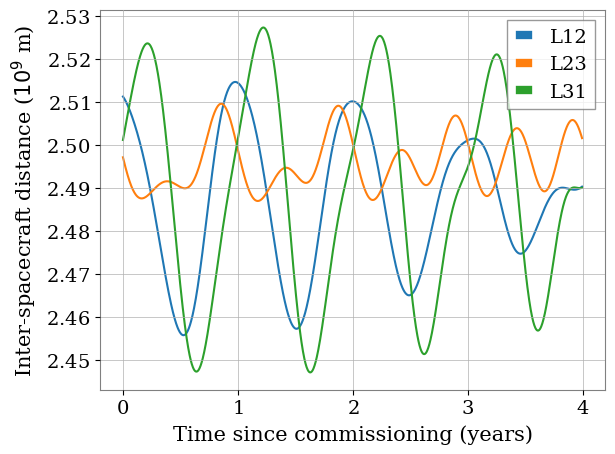

In [4]:
t = np.arange(0, orb_size*orb_dt, orb_dt)/(86400*365.25)

plt.figure(tight_layout=True)
plt.plot(t, L12)
plt.plot(t, L23)
plt.plot(t, L31)
plt.xlabel('Time since commissioning (years)')
plt.ylabel('Inter-spacecraft distance ($10^9$ m)')
plt.legend(['L12', 'L23', 'L31'])
plt.savefig(FIGURES / 'lisa_orbit.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 1

In [12]:
params = np.loadtxt(lpf_ord_param_path, skiprows=1)

lpf_betas = params[:, 0]
lpf_levels = params[:, 1]

bet_min = 1
amp_min, amp_max = 1e-16, 1e-10

lpf_levels = lpf_levels[lpf_betas > bet_min]
lpf_betas = lpf_betas[lpf_betas > bet_min]

lpf_betas = lpf_betas[(lpf_levels > amp_min) & (lpf_levels < amp_max)]
lpf_levels = lpf_levels[(lpf_levels > amp_min) & (lpf_levels < amp_max)]

In [14]:
with h5py.File(glitch_lm_dataset_path, "r") as h5:
    amp_array = h5["amp"][:]
    beta_array = h5["beta"][:]

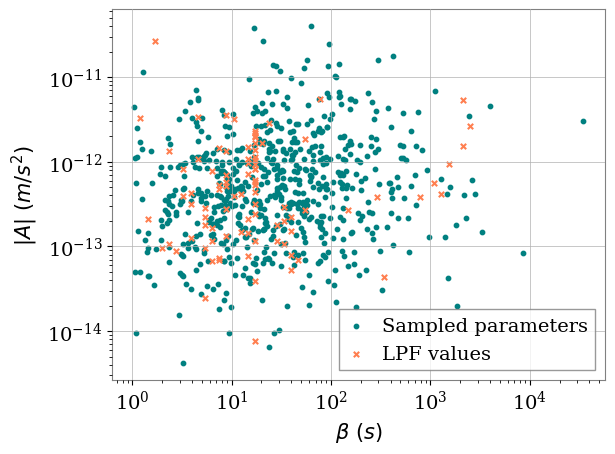

In [15]:
plt.figure(tight_layout=True)
plt.scatter(beta_array, amp_array, color='teal', s=10, label='Sampled parameters')
plt.scatter(lpf_betas, np.abs(lpf_levels), color='coral', s=15, marker='x', label='LPF values')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('$|A|\ (m/s^2)$')
plt.xlabel('$\\beta\ (s)$')
plt.legend()
plt.savefig(DIST/'figures'/'glitch_params.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 2

In [16]:
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(15 * 3600 / 0.25),
        't_inj': 5 * 3600, 'keep_noises': ['test-mass', 'oms']}

glitches, gws = [], []
    
run_simulation(gws, glitches, pipe,
                None, None, orbits_path,
                simulation_path,
                disable_noise=pipe['keep_noises'])
tdi_dict = run_tdi(simulation_path, pipe)

X, Y, Z = tdi_dict['X'].value, tdi_dict['Y'].value, tdi_dict['Z'].value
A = (Z - X)/np.sqrt(2)
E = (X - 2*Y + Z)/np.sqrt(6)
T = (X + Y + Z)/np.sqrt(3)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


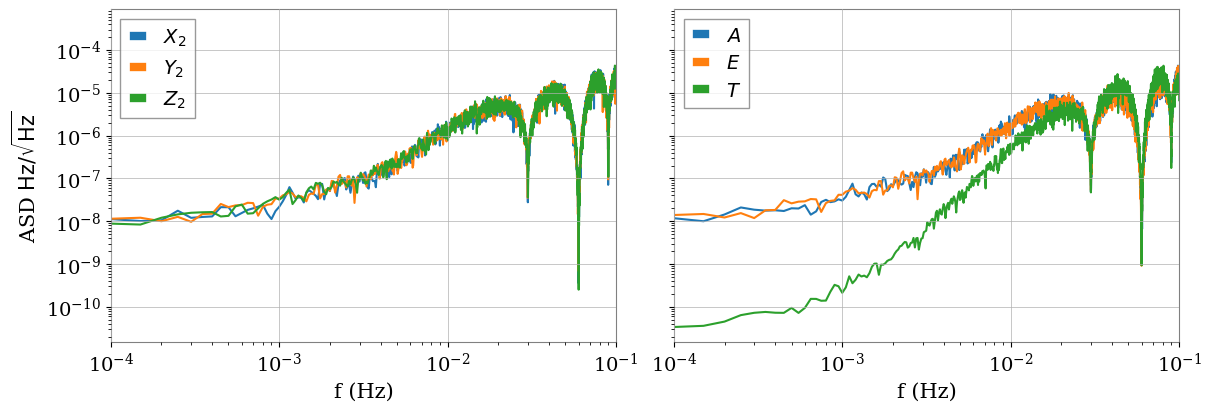

In [18]:
nperseg = 2e4/pipe['dt']
noverlap = None

SX_sim = estimate_psd(X, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
SY_sim = estimate_psd(Y, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
SZ_sim = estimate_psd(Z, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)

SA_sim = estimate_psd(A, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
SE_sim = estimate_psd(E, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
ST_sim = estimate_psd(T, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)

axes[0].loglog(SX_sim[0], np.sqrt(SX_sim[1]), label='$X_2$')
axes[0].loglog(SY_sim[0], np.sqrt(SY_sim[1]), label='$Y_2$')
axes[0].loglog(SZ_sim[0], np.sqrt(SZ_sim[1]), label='$Z_2$')

axes[1].loglog(SA_sim[0], np.sqrt(SA_sim[1]), label='$A$')
axes[1].loglog(SE_sim[0], np.sqrt(SE_sim[1]), label='$E$')
axes[1].loglog(ST_sim[0], np.sqrt(ST_sim[1]), label='$T$')

axes[0].set_xlabel('f (Hz)')
axes[0].set_ylabel('ASD $\\text{Hz}/\sqrt{\\text{Hz}}$')
axes[0].set_xlim(1e-4, 1e-1)
axes[0].legend()

axes[1].set_xlabel('f (Hz)') 
axes[1].set_xlim(1e-4, 1e-1)
axes[1].legend()

plt.savefig(FIGURES / 'noise_psd.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 3

In [19]:
gws = [{'type': 'BinaryInspiralGW', 'm1': 6e6, 'm2': 7e6, 'd': 1e3,
        'spin1': 0, 'spin2': 0, 't_inj': pipe['t_inj']+1*3600, 'domain': 'freq',
        'gw_beta':0, 'gw_lambda':0}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': pipe['t_inj']-1*3600, 'beta':17,
             'level':2*2.28e-12*17, 'inj_point':'tm_13'}]

run_simulation(
            gws, glitches, pipe,
            gw_path, glitch_path, orbits_path,
            simulation_path,
            disable_noise=pipe['keep_noises']
        )
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [20]:
event = {'t_inj':pipe['t_inj']}
res = 256
spec = SPECS['ext_high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

start = time.time()
QT_mixed = np.zeros((256, 256, 3))
for channel in ['A', 'E', 'T']:
    t_mixed, f_mixed, data = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
    QT_mixed[:, :, ['A', 'E', 'T'].index(channel)] = data
end = time.time()
print(end - start)

0.6085569858551025


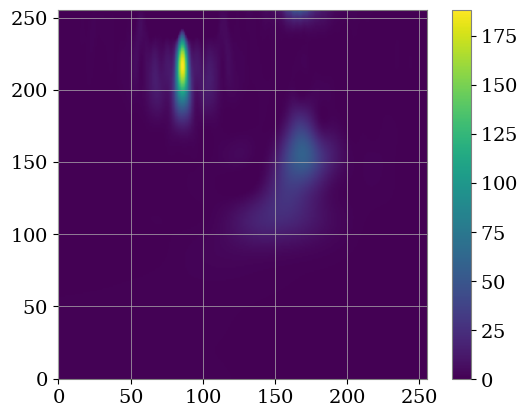

In [21]:
plt.imshow(QT_mixed[:, :, 0], origin='lower')
#plt.clim(0, 60)
plt.colorbar()
plt.show()

In [22]:
with h5py.File(gw_lm_dataset_path, "r") as h5:
    QT_gw_images = h5["QT"][25][:]
    t_gw_arr = h5["t_qscan"][25][:]
    f_gw_arr = h5["f_qscan"][25][:]

with h5py.File(glitch_hm_dataset_path, "r") as h5:
    QT_glitch_images = h5["QT"][25][:]
    t_glitch_arr = h5["t_qscan"][25][:]
    f_glitch_arr = h5["f_qscan"][25][:]

with h5py.File(empty_ehm_dataset_path, "r") as h5:
    QT_empty_images = h5["QT"][25][:]
    t_empty_arr = h5["t_qscan"][25][:]
    f_empty_arr = h5["f_qscan"][25][:]

In [23]:
channels = ['A', 'E', 'T']

QT_gw, t_gw, f_gw = QT_gw_images[4], t_gw_arr[4], f_gw_arr[4]
QT_glitch, t_glitch, f_glitch = QT_glitch_images[1], t_glitch_arr[1], f_glitch_arr[1]
QT_empty, t_empty, f_empty = QT_empty_images[0], t_empty_arr[0], f_empty_arr[0]
#QT_mixed, t_mixed, f_mixed = QT_mixed_images[2], t_mixed_arr[2], f_mixed_arr[2]

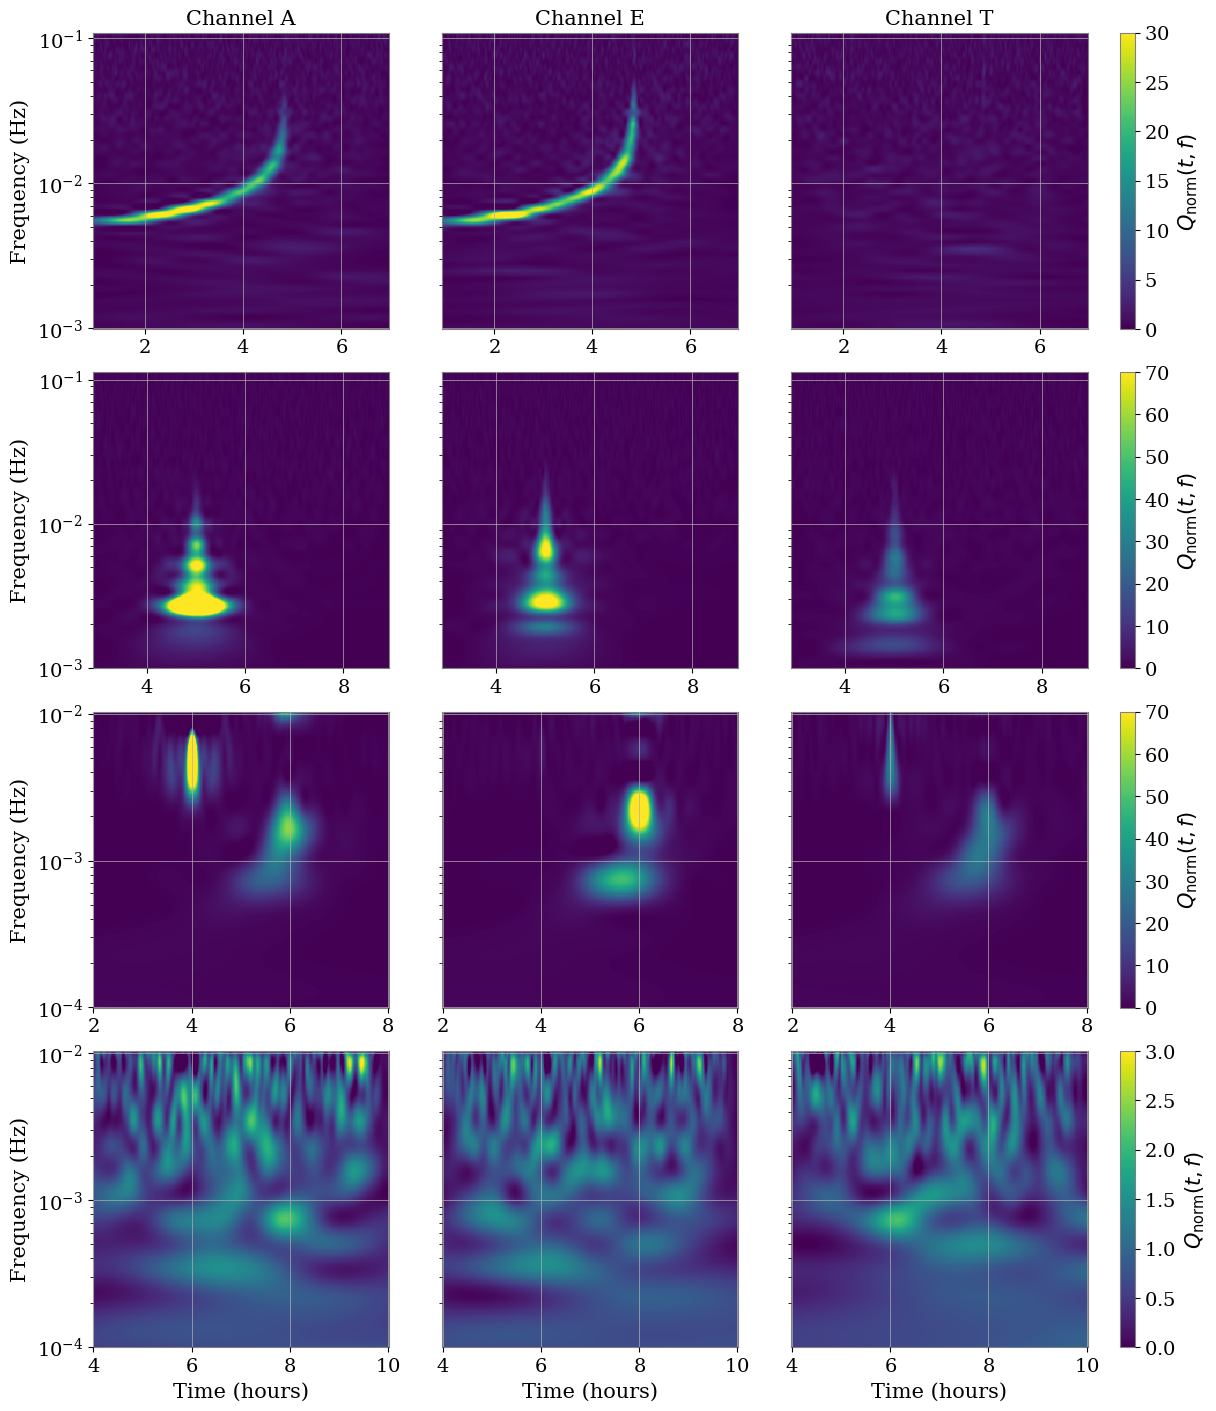

In [25]:
shrink = 1
fig, axes = plt.subplots(4, 3, figsize=(12,14), constrained_layout=True)

# share y within rows
for row in axes:
    for ax in row[1:]:
        ax.sharey(row[0])
        ax.tick_params(left=False, labelleft=False)

# ---------- ROW 0: GW ----------
ims = []
for i, ax in enumerate(axes[0, :]):
    ax.set_box_aspect(1)
    ax.set_yscale('log')
    im = ax.pcolormesh(t_gw/3600, f_gw, QT_gw[:,:,i], cmap='viridis',\
                        vmin=0, vmax=30)
    ims.append(im)
    
    ax.set_title(f'Channel {channels[i]}')
    if i == 0:
        ax.set_ylabel('Frequency (Hz)')

# ONE colorbar for whole row
fig.colorbar(ims[-1], ax=axes[0, :], fraction=0.02, pad=0.02, shrink=shrink, label='$Q_{\\text{norm}}(t,f)$')


# ---------- ROW 1: GLITCH ----------
ims = []
for i, ax in enumerate(axes[1, :]):
    ax.set_box_aspect(1)
    ax.set_yscale('log')
    im = ax.pcolormesh(t_glitch/3600, f_glitch, QT_glitch[:,:,i], cmap='viridis',\
                        vmin=0, vmax=70)
    ims.append(im)
    
    if i == 0:
        ax.set_ylabel('Frequency (Hz)')

fig.colorbar(ims[-1], ax=axes[1, :], fraction=0.02, pad=0.02, shrink=shrink, label='$Q_{\\text{norm}}(t,f)$')


# ---------- ROW 2: MIXED ----------
ims = []
for i, ax in enumerate(axes[2, :]):
    ax.set_box_aspect(1)
    ax.set_yscale('log')
    im = ax.pcolormesh(t_mixed/3600, f_mixed, QT_mixed[:,:,i], cmap='viridis',\
                        vmin=0, vmax=70)
    ims.append(im)
    
    if i == 0:
        ax.set_ylabel('Frequency (Hz)')

fig.colorbar(ims[-1], ax=axes[2, :], fraction=0.02, pad=0.02, shrink=shrink, label='$Q_{\\text{norm}}(t,f)$')


# ---------- ROW 3: EMPTY ----------
ims = []
for i, ax in enumerate(axes[3, :]):
    ax.set_box_aspect(1)
    ax.set_yscale('log')
    im = ax.pcolormesh(t_empty/3600, f_empty, QT_empty[:,:,i], cmap='viridis',\
                        vmin=0, vmax=3)
    ims.append(im)
    
    ax.set_xlabel('Time (hours)')
    if i == 0:
        ax.set_ylabel('Frequency (Hz)')

fig.colorbar(ims[-1], ax=axes[3, :], fraction=0.02, pad=0.02, shrink=shrink, label='$Q_{\\text{norm}}(t,f)$')
plt.savefig(FIGURES / 'example_qscans.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 6

In [27]:
lm_results_path = TRAINING_RESULTS/ 'low_mass'/ 'run_260626_151227'
lm_results = torch.load(lm_results_path / 'results.pt')
lm_iters, lm_train_loss, lm_valid_loss, *_ = lm_results

data = np.load(lm_results_path / 'roc_curves.npz')

fpr_gw_lm = data["fpr_gw"]
tpr_gw_lm = data["tpr_gw"]
auc_gw_lm = data["auc_gw"]

fpr_glitch_lm = data["fpr_glitch"]
tpr_glitch_lm = data["tpr_glitch"]
auc_glitch_lm = data["auc_glitch"]

lm_cm = np.load(lm_results_path / 'confusion_matrix.npz')['cm']

hm_results_path = TRAINING_RESULTS/ 'high_mass'/ 'good_runs' /'run_230626_000227'
hm_results = torch.load(hm_results_path / 'results.pt')
hm_iters, hm_train_loss, hm_valid_loss, *_ = hm_results

data = np.load(hm_results_path / 'roc_curves.npz')

fpr_gw_hm = data["fpr_gw"]
tpr_gw_hm = data["tpr_gw"]
auc_gw_hm = data["auc_gw"]

fpr_glitch_hm = data["fpr_glitch"]
tpr_glitch_hm = data["tpr_glitch"]
auc_glitch_hm = data["auc_glitch"]

hm_cm = np.load(hm_results_path / 'confusion_matrix.npz')['cm']

ehm_results_path = TRAINING_RESULTS/ 'ext_high_mass'/ 'good_runs' /'run_210626_163120'
ehm_results = torch.load(ehm_results_path / 'results.pt')
ehm_iters, ehm_train_loss, ehm_valid_loss, *_ = ehm_results

data = np.load(ehm_results_path / 'roc_curves.npz')

fpr_gw_ehm = data["fpr_gw"]
tpr_gw_ehm = data["tpr_gw"]
auc_gw_ehm = data["auc_gw"]

fpr_glitch_ehm = data["fpr_glitch"]
tpr_glitch_ehm = data["tpr_glitch"]
auc_glitch_ehm = data["auc_glitch"]

ehm_cm = np.load(ehm_results_path / 'confusion_matrix.npz')['cm']

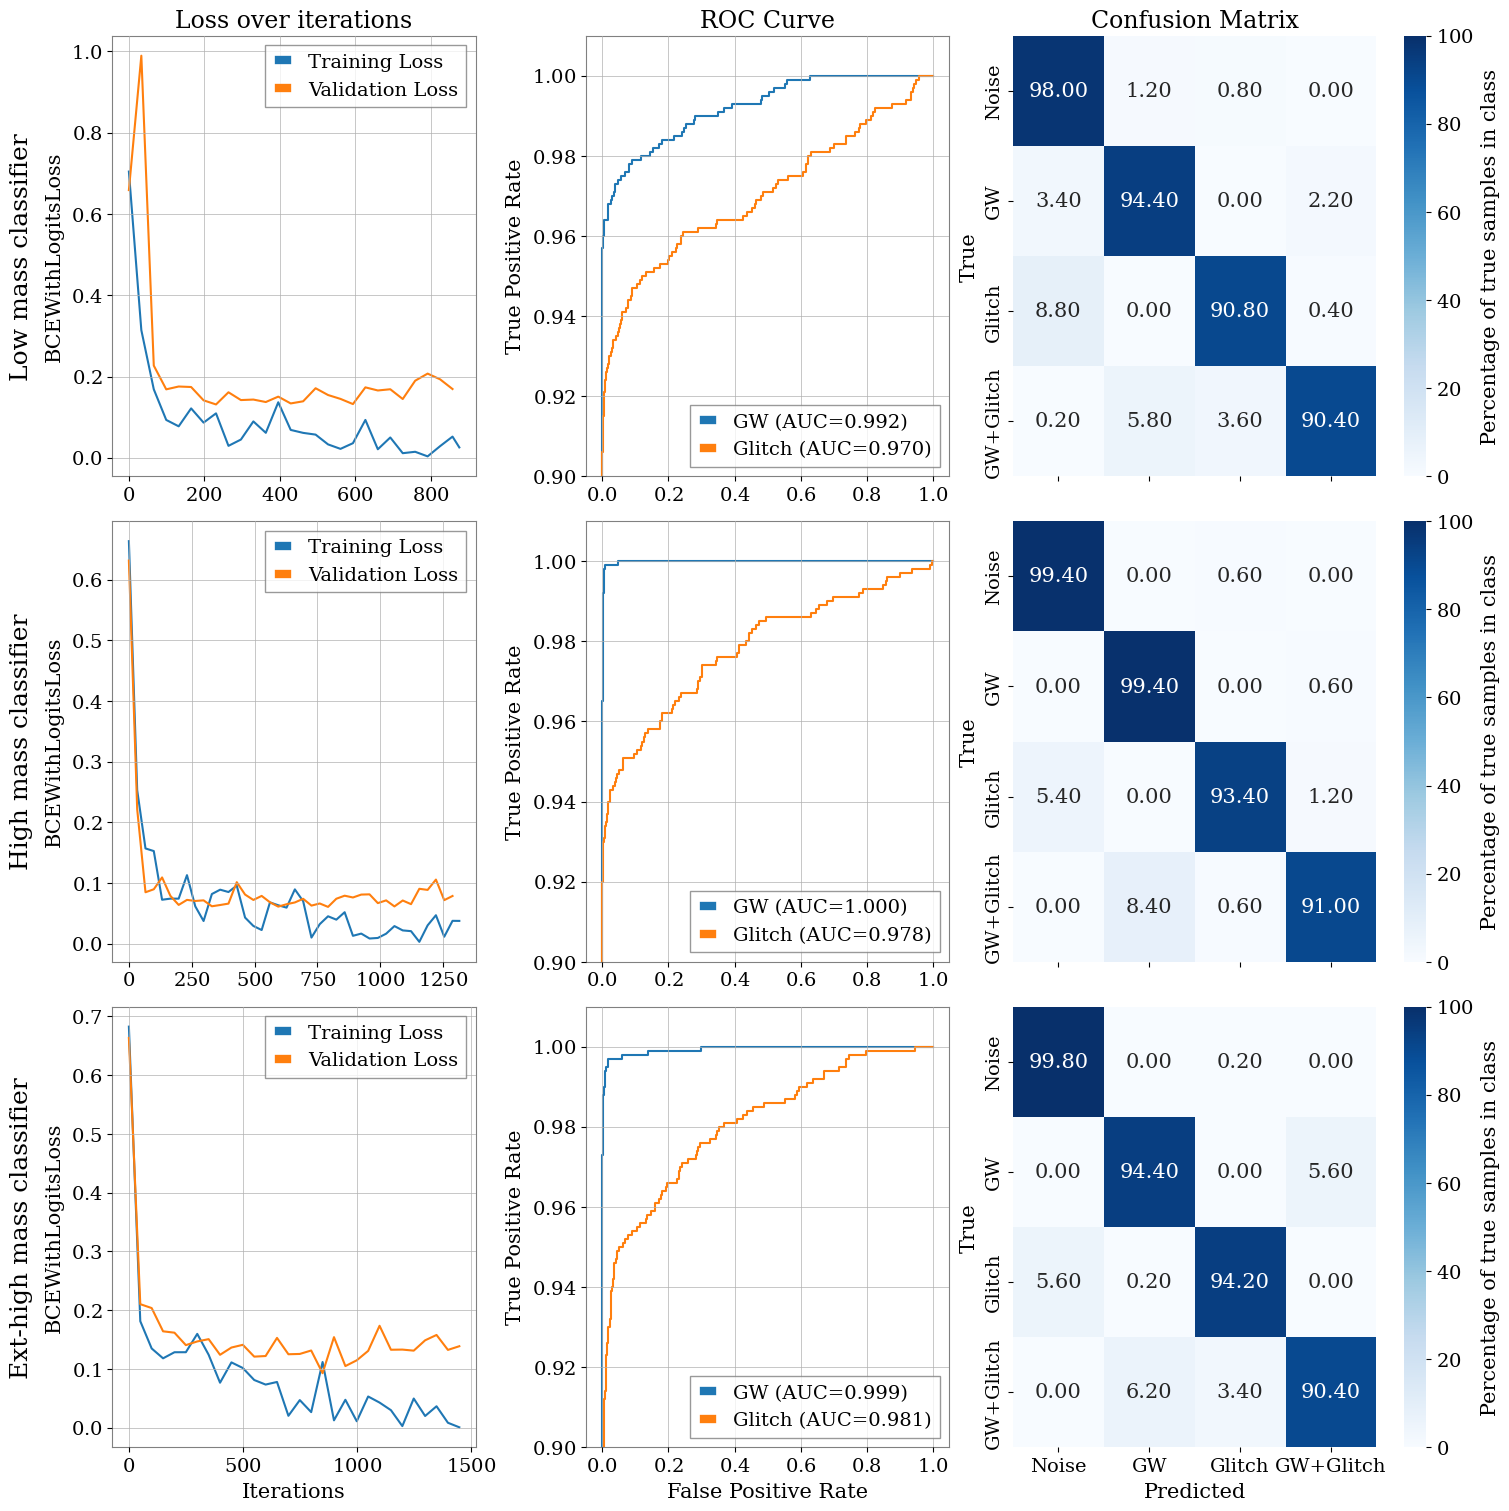

In [28]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(15, 15),
    constrained_layout=True
)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]
label_size = mpl.rcParams["axes.labelsize"]

# ======================================================================
# LOW MASS
# ======================================================================

# Loss
axes[0,0].plot(
    lm_iters[:len(lm_train_loss)],
    lm_train_loss,
    label='Training Loss'
)
axes[0,0].plot(
    lm_iters[:len(lm_valid_loss)],
    lm_valid_loss,
    label='Validation Loss'
)

axes[0,0].set_ylabel("BCEWithLogitsLoss")
axes[0,0].set_title("Loss over iterations")
axes[0,0].legend()

axes[0,0].text(
    -0.25, 0.5,
    "Low mass classifier",
    transform=axes[0,0].transAxes,
    rotation=90,
    fontsize=label_size*1.2,
    va='center',
    ha='center'
)

# ROC
axes[0,1].plot(
    fpr_gw_lm,
    tpr_gw_lm,
    label=f"GW (AUC={auc_gw_lm:.3f})"
)

axes[0,1].plot(
    fpr_glitch_lm,
    tpr_glitch_lm,
    label=f"Glitch (AUC={auc_glitch_lm:.3f})"
)

#axes[0,1].set_xlim(0,1)
axes[0,1].set_ylim(0.9,1.01)
axes[0,1].set_ylabel("True Positive Rate")
axes[0,1].set_title("ROC Curve")
axes[0,1].legend()

# Confusion matrix
sns.heatmap(
    lm_cm,
    annot=True,
    cmap="Blues",
    ax=axes[0,2],
    fmt=".2f",
    xticklabels=labels_names,
    yticklabels=labels_names,
    vmin=0,
    vmax=100
)

axes[0,2].tick_params(axis='x', labelbottom=False)
axes[0,2].set_ylabel("True")
axes[0,2].set_title("Confusion Matrix")
axes[0,2].collections[0].colorbar.set_label(
    "Percentage of true samples in class"
)
axes[0,2].grid(False)

# ======================================================================
# HIGH MASS
# ======================================================================

# Loss
axes[1,0].plot(
    hm_iters[:len(hm_train_loss)],
    hm_train_loss,
    label="Training Loss"
)

axes[1,0].plot(
    hm_iters[:len(hm_valid_loss)],
    hm_valid_loss,
    label="Validation Loss"
)

axes[1,0].set_ylabel("BCEWithLogitsLoss")
axes[1,0].legend()

axes[1,0].text(
    -0.25,0.5,
    "High mass classifier",
    transform=axes[1,0].transAxes,
    rotation=90,
    fontsize=label_size*1.2,
    va='center',
    ha='center'
)

# ROC
axes[1,1].plot(
    fpr_gw_hm,
    tpr_gw_hm,
    label=f"GW (AUC={auc_gw_hm:.3f})"
)

axes[1,1].plot(
    fpr_glitch_hm,
    tpr_glitch_hm,
    label=f"Glitch (AUC={auc_glitch_hm:.3f})"
)

#axes[1,1].set_xlim(0,1)
axes[1,1].set_ylim(0.9,1.01)
axes[1,1].set_ylabel("True Positive Rate")
axes[1,1].legend()

# Confusion matrix
sns.heatmap(
    hm_cm,
    annot=True,
    cmap="Blues",
    ax=axes[1,2],
    fmt=".2f",
    xticklabels=labels_names,
    yticklabels=labels_names,
    vmin=0,
    vmax=100
)

axes[1,2].tick_params(axis='x', labelbottom=False)
axes[1,2].set_ylabel("True")
axes[1,2].collections[0].colorbar.set_label(
    "Percentage of true samples in class"
)
axes[1,2].grid(False)

# ======================================================================
# EXT HIGH MASS
# ======================================================================

# Loss
axes[2,0].plot(
    ehm_iters[:len(ehm_train_loss)][:30],
    ehm_train_loss[:30],
    label="Training Loss"
)

axes[2,0].plot(
    ehm_iters[:len(ehm_valid_loss)][:30],
    ehm_valid_loss[:30],
    label="Validation Loss"
)

axes[2,0].set_xlabel("Iterations")
axes[2,0].set_ylabel("BCEWithLogitsLoss")
axes[2,0].legend()

axes[2,0].text(
    -0.25,0.5,
    "Ext-high mass classifier",
    transform=axes[2,0].transAxes,
    rotation=90,
    fontsize=label_size*1.2,
    va='center',
    ha='center'
)

# ROC
axes[2,1].plot(
    fpr_gw_ehm,
    tpr_gw_ehm,
    label=f"GW (AUC={auc_gw_ehm:.3f})"
)

axes[2,1].plot(
    fpr_glitch_ehm,
    tpr_glitch_ehm,
    label=f"Glitch (AUC={auc_glitch_ehm:.3f})"
)

#axes[2,1].set_xlim(0,1)
axes[2,1].set_ylim(0.9,1.01)
axes[2,1].set_xlabel("False Positive Rate")
axes[2,1].set_ylabel("True Positive Rate")
axes[2,1].legend()

# Confusion matrix
sns.heatmap(
    ehm_cm,
    annot=True,
    cmap="Blues",
    ax=axes[2,2],
    fmt=".2f",
    xticklabels=labels_names,
    yticklabels=labels_names,
    vmin=0,
    vmax=100
)

axes[2,2].set_xlabel("Predicted")
axes[2,2].set_ylabel("True")
axes[2,2].collections[0].colorbar.set_label(
    "Percentage of true samples in class"
)
axes[2,2].grid(False)

plt.savefig(FIGURES / "model_performance.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 7

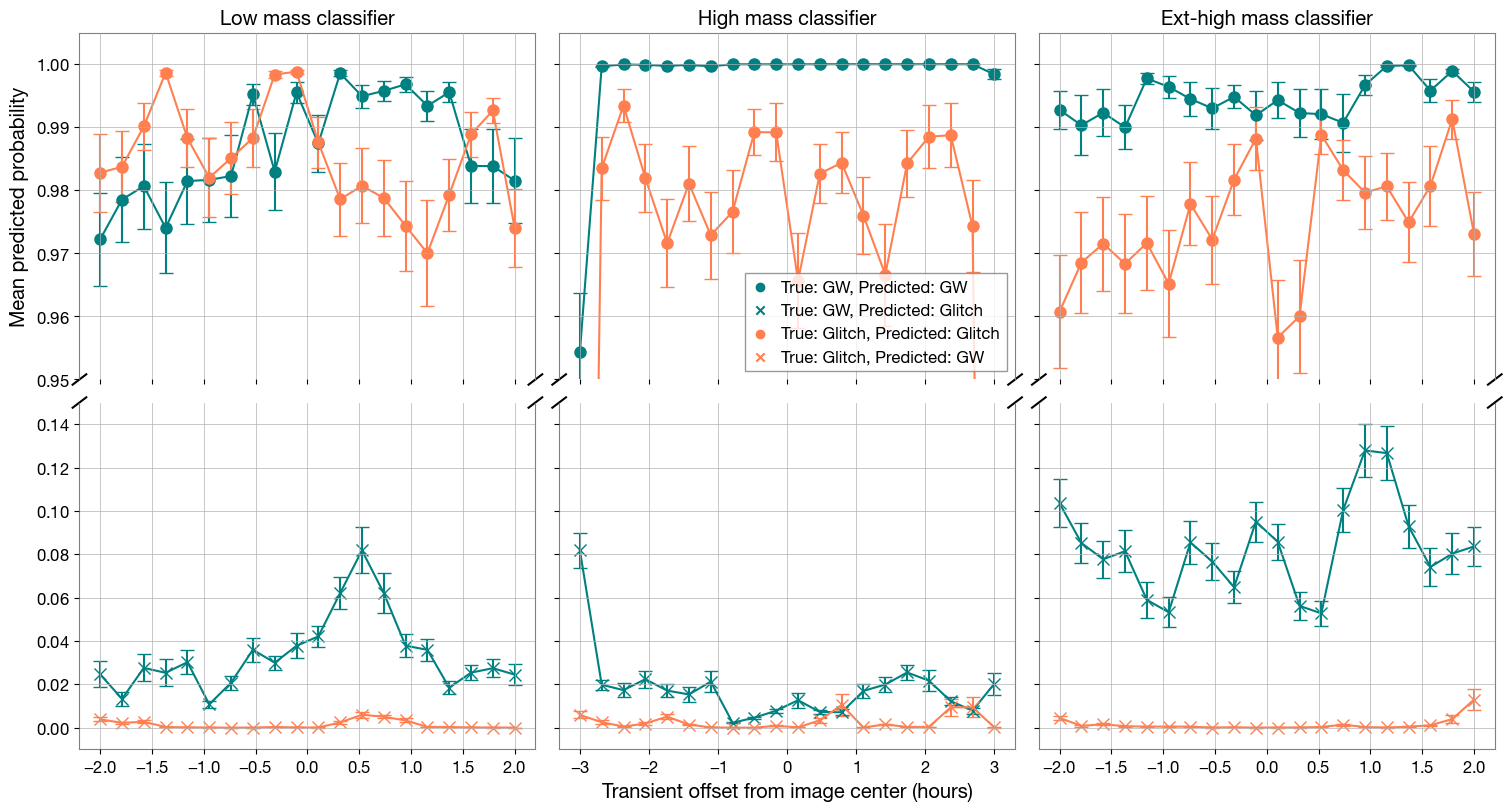

In [4]:
fig = plt.figure(figsize=(15, 8), constrained_layout=True)

categories = ['low_mass', 'high_mass', 'ext_high_mass']
titles = ['Low mass classifier', 'High mass classifier', 'Ext-high mass classifier']

# create 2 rows × 3 columns (top + bottom for each)
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])

axes_top = []
axes_bot = []

for i in range(3):
    if i == 0:
        axes_top.append(fig.add_subplot(gs[0, i]))
        axes_bot.append(fig.add_subplot(gs[1, i], sharex=axes_top[i]))
    else:
        axes_top.append(fig.add_subplot(gs[0, i], sharey=axes_top[0]))
        axes_bot.append(fig.add_subplot(gs[1, i], sharex=axes_top[i], sharey=axes_bot[0]))

for i in range(1, 3):
    axes_top[i].tick_params(labelleft=False)
    axes_bot[i].tick_params(labelleft=False)

for i, category in enumerate(categories):
    save_dir = INFERENCE_DATASETS / 'timecen_datasets' / category
    results = np.load(save_dir / 'inference_results.npz')

    times = results['times'] / 3600
    gw_acc = results['gw_acc']
    glitch_acc = results['glitch_acc']
    gw_std = results['gw_std']
    glitch_std = results['glitch_std']

    # plot on BOTH axes
    s = 8
    for ax in [axes_top[i], axes_bot[i]]:
        ax.errorbar(times, gw_acc[:,0], yerr=gw_std[:,0]/len(gw_std[:,0]), marker='o', markersize=s, color='teal', capsize=5)
        ax.errorbar(times, gw_acc[:,1], yerr=gw_std[:,1]/len(gw_std[:,0]), marker='x', markersize=s, color='teal', capsize=5)
        ax.errorbar(times, glitch_acc[:,1], yerr=glitch_std[:,1]/len(gw_std[:,0]), marker='o', markersize=s, color='coral', capsize=5)
        ax.errorbar(times, glitch_acc[:,0], yerr=glitch_std[:,0]/len(gw_std[:,0]), marker='x', markersize=s, color='coral', capsize=5)

    # set limits
    axes_top[i].set_ylim(0.95, 1.005)
    axes_bot[i].set_ylim(-0.01, 0.15)

    # titles / labels
    axes_top[i].set_title(titles[i])

    # remove middle spines
    axes_top[i].spines['bottom'].set_visible(False)
    axes_bot[i].spines['top'].set_visible(False)

    axes_top[i].tick_params(labelbottom=False)
    axes_bot[i].xaxis.tick_bottom()

    # diagonal break marks
    d = 0.015
    kwargs = dict(transform=axes_top[i].transAxes, color='k', clip_on=False)
    axes_top[i].plot((-d, +d), (-d, +d), **kwargs)
    axes_top[i].plot((1-d, 1+d), (-d, +d), **kwargs)

    kwargs.update(transform=axes_bot[i].transAxes)
    axes_bot[i].plot((-d, +d), (1-d, 1+d), **kwargs)
    axes_bot[i].plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# y-label only once
axes_top[0].set_ylabel('Mean predicted probability')
axes_bot[1].set_xlabel('Transient offset from image center (hours)')

# legend (only once)
axes_top[1].scatter([], [], marker='o', color='teal', label='True: GW, Predicted: GW')
axes_top[1].scatter([], [], marker='x', color='teal', label='True: GW, Predicted: Glitch')
axes_top[1].scatter([], [], marker='o', color='coral', label='True: Glitch, Predicted: Glitch')
axes_top[1].scatter([], [], marker='x', color='coral', label='True: Glitch, Predicted: GW')
axes_top[1].legend(fontsize=12)

#plt.ylabel('Mean predicted probability')
#plt.savefig(FIGURES / 'time_centering.png', dpi=300, bbox_inches='tight')
plt.show()